# Notebook 1 — Linear fit with uncertainties

**Objective:** understand how to fit a straight-line model to measurements with known uncertainties.

The model is

$$
y_i = b + m x_i,
$$

where:

- $x_i$ is the independent-variable value, treated as exact;
- $y_i$ is the observed dependent-variable value;
- $\sigma_{y,i}$ is its standard uncertainty;
- $b$ and $m$ are the intercept and slope to estimate.

We assume independent Gaussian errors in $y$ and neglect uncertainties in $x$.

## Warm-up: simulated linear data

Before fitting the published dataset, we generate a small synthetic example to visualize how Gaussian measurement noise scatters observations around a straight line. The `_sim` suffix keeps these variables separate from the published data used below.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("default")

In [2]:
rng = np.random.default_rng(seed=42)

m_true = 2.5
b_true = 1.0

x_sim = np.linspace(0, 10, 20)
sigma_y_sim = np.ones_like(x_sim)

y_true_sim = m_true * x_sim + b_true
y_obs_sim = y_true_sim + rng.normal(0, sigma_y_sim)

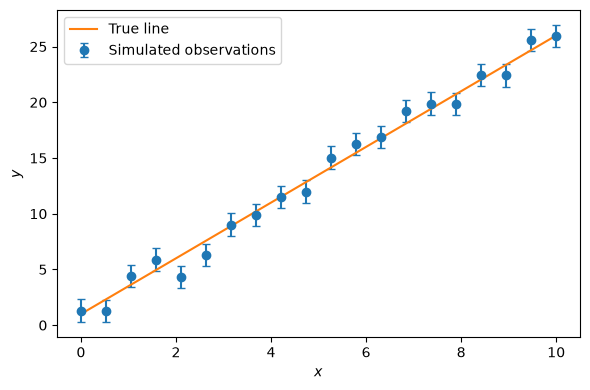

In [3]:
plt.figure(figsize=(6, 4))

plt.errorbar(
    x_sim,
    y_obs_sim,
    yerr=sigma_y_sim,
    fmt="o",
    capsize=3,
    label="Simulated observations",
)

plt.plot(x_sim, y_true_sim, label="True line")
plt.xlabel(r"$x$")
plt.ylabel(r"$y$")
plt.legend()
plt.tight_layout()
plt.show()

## Exercise 1: straight-line fit with uncertainties

**Source:** Exercise 1 and Table 1 (data points 5–20) from
D. W. Hogg, J. Bovy, and D. Lang,
[*Data analysis recipes: Fitting a model to data*](https://arxiv.org/abs/1008.4686) (2010).

**Task (adapted from the source):** Use the standard linear-algebra solution to fit $y=b+mx$ to data points 5–20, using only $x_i$, $y_i$, and $\sigma_{y,i}$. Treat $x_i$ as exact, so the tabulated $\sigma_{x,i}$ and $\rho_{xy,i}$ columns are retained below for provenance but deliberately not used. Plot the measurements with their uncertainties and the best-fit line, then compute the slope variance $\sigma_m^2$ and its standard uncertainty $\sigma_m$.

In [4]:
point_id = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10,
               11, 12, 13, 14, 15, 16, 17, 18, 19, 20])

x = np.array([201, 244, 47, 287, 203, 58, 210, 202, 198, 158,
              165, 201, 157, 131, 166, 160, 186, 125, 218, 146])

y = np.array([592, 401, 583, 402, 495, 173, 479, 504, 510, 416,
              393, 442, 317, 311, 400, 337, 423, 334, 533, 344])

sigma_y = np.array([61, 25, 38, 15, 21, 15, 27, 14, 30, 16,
                    14, 25, 52, 16, 34, 31, 42, 26, 16, 22])

sigma_x = np.array([9, 4, 11, 7, 5, 9, 4, 4, 11, 7,
                    5, 5, 5, 6, 6, 5, 9, 8, 6, 5])

rho_xy = np.array([-0.84, 0.31, 0.64, -0.27, -0.33,
                   0.67, -0.02, -0.05, -0.84, -0.69,
                   0.30, -0.46, -0.03, 0.50, 0.73,
                   -0.52, 0.90, 0.40, -0.78, -0.56])

In [5]:
mask = point_id >= 5

x_fit = x[mask]
y_fit = y[mask]
sigma_y_fit = sigma_y[mask]

In [6]:
u = np.ones_like(x_fit)
A = np.column_stack((u, x_fit))
C = np.diag(sigma_y_fit**2)

theta_hat = (np.linalg.inv(A.T @ np.linalg.inv(C) @ A) @ (A.T @ np.linalg.inv(C) @ y_fit))

b, m = theta_hat

print("theta_hat = [b, m] =", theta_hat)

theta_hat = [b, m] = [34.04772776  2.23992083]


In [7]:
print("y_fit shape:", y_fit.shape)
print("A shape:", A.shape)
print("C shape:", C.shape)
print("theta_hat shape:", theta_hat.shape)

y_fit shape: (16,)
A shape: (16, 2)
C shape: (16, 16)
theta_hat shape: (2,)


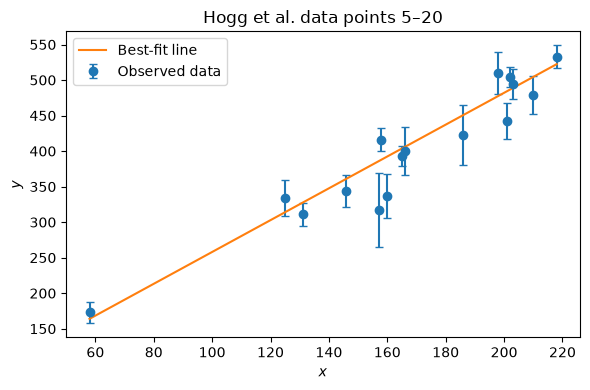

In [8]:
plt.figure(figsize=(6, 4))

plt.errorbar(x_fit,y_fit,yerr=sigma_y_fit,fmt="o",capsize=3,label="Observed data",)

x_line = np.linspace(min(x_fit), max(x_fit), 100)
y_line = m * x_line + b

plt.plot(x_line, y_line, label="Best-fit line")
plt.xlabel(r"$x$")
plt.ylabel(r"$y$")
plt.title("Hogg et al. data points 5–20")
plt.legend()
plt.tight_layout()
plt.show()

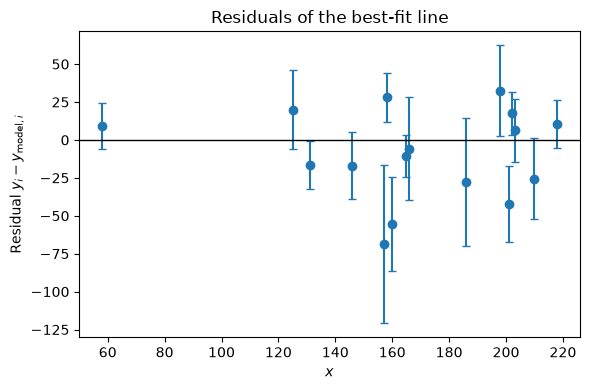

In [9]:
y_model = m * x_fit + b
residuals = y_fit - y_model

plt.figure(figsize=(6, 4))
plt.errorbar(x_fit,residuals,yerr=sigma_y_fit,fmt="o",capsize=3,)

plt.axhline(0, color="black", linewidth=1)
plt.xlabel(r"$x$")
plt.ylabel(r"Residual $y_i-y_{\mathrm{model},i}$")
plt.title("Residuals of the best-fit line")
plt.tight_layout()
plt.show()

In [10]:
chi2 = np.sum((residuals / sigma_y_fit) ** 2)

n_parameters = 2  # intercept b and slope m
dof = len(y_fit) - n_parameters
chi2_reduced = chi2 / dof

print(f"chi^2 = {chi2:.4f}")
print(f"degrees of freedom = {dof}")
print(f"reduced chi^2 = {chi2_reduced:.4f}")

chi^2 = 18.6808
degrees of freedom = 14
reduced chi^2 = 1.3343


In [11]:
cov_theta = np.linalg.inv(A.T @ np.linalg.inv(C) @ A)

sigma_b = np.sqrt(cov_theta[0, 0])
sigma_m = np.sqrt(cov_theta[1, 1])

rho_bm = cov_theta[0, 1] / (sigma_b * sigma_m)

print("Parameter covariance matrix:")
print(cov_theta)
print(f"b = {b:.4f} ± {sigma_b:.4f}")
print(f"m = {m:.5f} ± {sigma_m:.5f}")
print(f"correlation rho_bm = {rho_bm:.4f}")

Parameter covariance matrix:
[[ 3.32922601e+02 -1.88954491e+00]
 [-1.88954491e+00  1.16166311e-02]]
b = 34.0477 ± 18.2462
m = 2.23992 ± 0.10778
correlation rho_bm = -0.9608


In [12]:
sigma_m_squared = cov_theta[1, 1]
print(f"Slope variance sigma_m^2 = {sigma_m_squared:.7f}")

Slope variance sigma_m^2 = 0.0116166


### Interpretation of the linear fit

For the $N=16$ selected measurements, the model is

$$
y_i=b+mx_i.
$$

The parameter vector and design matrix are

$$
\theta=
\begin{pmatrix}
b\\
m
\end{pmatrix}
\in\mathbb{R}^2,
\qquad
A=
\begin{pmatrix}
1 & x_1\\
\vdots & \vdots\\
1 & x_N
\end{pmatrix}
\in\mathbb{R}^{N\times2}.
$$

Therefore, $A\theta\in\mathbb{R}^N$ is the vector of model predictions.

Because the observational errors are assumed independent, the data covariance matrix is diagonal:

$$
C=
\operatorname{diag}
\left(
\sigma_{y,1}^2,\ldots,\sigma_{y,N}^2
\right)
\in\mathbb{R}^{N\times N}.
$$

The weighted least-squares estimator is

$$
\hat{\theta}
=
\left(A^T C^{-1}A\right)^{-1}
A^T C^{-1}y.
$$

The residual vector is

$$
r=y-A\hat{\theta}\in\mathbb{R}^N.
$$

The chi-squared statistic is

$$
\chi^2=r^T C^{-1}r,
$$

or, because $C$ is diagonal,

$$
\chi^2
=
\sum_i
\frac{r_i^2}{\sigma_{y,i}^2}.
$$

With two fitted parameters, the number of degrees of freedom is

$$
\nu=N-2=14,
$$

and the reduced chi-squared is $\chi_\nu^2=\chi^2/\nu$.

The covariance matrix of the fitted parameters is

$$
\operatorname{Cov}(\hat{\theta})
=
\left(A^T C^{-1}A\right)^{-1}
\in\mathbb{R}^{2\times2}.
$$

Its diagonal entries are the parameter variances:

$$
\sigma_b
=
\sqrt{\operatorname{Cov}(\hat{\theta})_{00}},
\qquad
\sigma_m
=
\sqrt{\operatorname{Cov}(\hat{\theta})_{11}}.
$$

The off-diagonal entry gives the correlation between the intercept and slope:

$$
\rho_{bm}
=
\frac{\operatorname{Cov}(b,m)}
{\sigma_b\sigma_m}
=
-0.9608.
$$

The strong negative correlation means that an increase in the slope can be partly compensated by a decrease in the intercept.

Because the example does not assign physical units to $x$ and $y$, the parameters are expressed in the corresponding numerical units: $b$ has the units of $y$, $m$ has the units of $y/x$, and $\sigma_m^2$ has the units of $(y/x)^2$.

## Conclusion

Using Hogg et al. data points 5–20, treating $x_i$ as exact and the $y_i$ errors as independent and Gaussian, the weighted straight-line fit gives

$$
b=34.05\pm18.25,
\qquad
m=2.2399\pm0.1078.
$$

The quantity explicitly requested in the exercise is the slope variance:

$$
\boxed{\sigma_m^2=0.01162}.
$$

The goodness-of-fit values are $\chi^2=18.68$ for $\nu=14$ degrees of freedom and $\chi_\nu^2=1.33$. Under the stated assumptions, this does not reveal an obvious mismatch between the linear model and the quoted uncertainties, although it does not prove that the model is correct.

Finally, $\rho_{bm}=-0.9608$ shows that the fitted intercept and slope are strongly negatively correlated. The fitted slope agrees with the expected result, $m\approx2.24\pm0.11$.